# Identifying Walkability-Related Studies in Smart City Research
## Embedding Similarity + Zero-Shot Classification (replaces the fine-tuned DeBERTa pipeline)

Este notebook substitui `05_GenAI_Classification.ipynb`. Em vez do DeBERTa fine-tuned
(que memorizou os dados sintéticos e colapsou para recall ~0.245 nos abstracts reais),
usamos dois métodos que não dependem de treino em dados sintéticos:

1. **Embedding similarity** — similaridade de cosseno entre o embedding do texto e o
   embedding de uma frase-âncora ("this article uses sensor data to measure walkability").
2. **Zero-shot classification (NLI)** — um classificador zero-shot pré-treinado avalia a
   mesma pergunta como hipótese, sem nenhum treino específico no seu domínio.

**Pipeline:**
- Passo 1: rodar os dois métodos no `real.json` (conjunto real adjudicado, ~67 abstracts)
  para obter métricas (recall, precision, F1, WSS@95) e calibrar o threshold de decisão.
- Passo 2: aplicar os métodos calibrados no corpus completo (o mesmo arquivo usado pelo
  notebook original, `04_document_search_results_with_intros_and_contributions.json`).
- Passo 3: salvar os resultados (scores completos + subconjunto filtrado).

> **Nota:** este notebook foi construído a partir da estrutura do notebook original que
> você enviou, mas eu não tenho acesso ao seu `real.json` nem ao arquivo `04_...json`
> neste ambiente — então os caminhos, nomes de campos e formatos abaixo são inferidos e
> ficam centralizados na seção CONFIG. Rode localmente e ajuste o que não bater (o
> notebook imprime diagnósticos claros se um campo esperado não existir).

In [4]:
# Import Required Libraries
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
)

pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

os.environ["TOKENIZERS_PARALLELISM"] = "false"

DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                             "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {TORCH_DEVICE}")

Using device: cuda


## Configuration

Ajuste estes caminhos e nomes de campo antes de rodar. Os defaults seguem a convenção
do notebook original (`../data/...`) e o nome de campo `contribution` que ele usa para
o texto classificado.

- `REAL_DATA_PATH`: o `real.json` com os ~67 abstracts adjudicados (rótulo humano).
- `MAIN_DATA_PATH`: o corpus completo, mesmo arquivo do notebook original.
- `TEXT_FIELD_CANDIDATES`: nomes de campo tentados, em ordem, para extrair o texto de
  cada registro (tenta o primeiro que existir e não for vazio).
- `LABEL_FIELD_CANDIDATES`: idem, para o rótulo humano no `real.json`.
- `POSITIVE_LABEL_VALUES`: quais valores de rótulo contam como positivo (ajuste se o
  seu `real.json` usa 1/0, True/False, "positive"/"negative", etc. — todos os
  candidatos abaixo são tentados).

In [5]:
CONFIG = {
    "REAL_DATA_PATH": "../model/dataset/real.json",
    "MAIN_DATA_PATH": "../data/04_document_search_results_with_intros_and_contributions.json",

    "TEXT_FIELD_CANDIDATES": ["contribution", "abstract", "text", "contribution_text"],
    "LABEL_FIELD_CANDIDATES": ["label", "is_walkability_related", "walkability", "y", "class"],
    "POSITIVE_LABEL_VALUES": {
        1, "1", True, "true", "True", "positive", "Positive", "yes", "Yes",
        "related", "Related", "walkability-related", "walkability related",
        "sensing of walkability dimension", "Sensing of walkability dimension",
    },

    "EMBEDDING_MODEL_NAME": "sentence-transformers/all-mpnet-base-v2",
    # Same zero-shot model already referenced (commented out) in the original notebook,
    # kept for continuity with earlier experimentation in this project.
    "ZEROSHOT_MODEL_NAME": "MoritzLaurer/deberta-v3-large-zeroshot-v2.0-c",

    # Anchor phrase used both as the embedding-similarity target and (via
    # hypothesis_template) as the zero-shot NLI hypothesis.
    "POSITIVE_ANCHOR": "This article uses data from a sensor to measure walkability.",
    "NEGATIVE_ANCHOR": "This article does not use sensor data to measure walkability.",

    "ZEROSHOT_CANDIDATE_LABELS": [
        "uses sensor data to measure a walkability dimension",
        "does not use sensor data to measure walkability",
    ],
    "ZEROSHOT_HYPOTHESIS_TEMPLATE": "This article {}.",

    # Screening threshold is calibrated to hit at least this recall on real.json,
    # consistent with the WSS@95 benchmark already used elsewhere in the project.
    "TARGET_RECALL": 0.95,

    "OUTPUT_DIR": "../data",
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

## Helper functions

`get_text` tenta os campos candidatos em ordem. `get_label` normaliza o rótulo humano
para 0/1. `wss_at_recall` implementa Work Saved over Sampling no ponto de recall alvo
(Cohen et al., 2006): `WSS@X = (TN + FN) / N - (1 - X)`, calculado no threshold mais
baixo que ainda garante recall >= X.

In [6]:
def get_text(record, field_candidates=CONFIG["TEXT_FIELD_CANDIDATES"]):
    for field in field_candidates:
        val = record.get(field)
        if isinstance(val, str) and val.strip():
            return val.strip()
    return None


def get_label(record, field_candidates=CONFIG["LABEL_FIELD_CANDIDATES"],
              positive_values=CONFIG["POSITIVE_LABEL_VALUES"]):
    for field in field_candidates:
        if field in record and record[field] is not None:
            value = record[field]
            if isinstance(value, str):
                normalized = value.strip().lower()
                positive_text = {
                    "1", "true", "yes", "positive", "related",
                    "walkability-related", "walkability related",
                    "sensing of walkability dimension",
                    "sensor-based walkability",
                    "sensor data to measure walkability",
                }
                negative_text = {
                    "0", "false", "no", "negative", "not related",
                    "not-related", "not walkability related",
                    "non-related", "unrelated",
                }
                if normalized in positive_text:
                    return 1
                if normalized in negative_text:
                    return 0
                if "related" in normalized and "not" not in normalized:
                    return 1
                if "not related" in normalized or "unrelated" in normalized:
                    return 0
            return 1 if value in positive_values else 0
    return None


def _confusion_counts(y_true, y_pred):
    """Return tn, fp, fn, tp robustly for single-class or empty-positive cases."""
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (1, 1):
        label = y_true[0] if len(y_true) else 0
        if label == 1:
            tn, fp, fn, tp = 0, 0, 0, len(y_pred)
        else:
            tn, fp, fn, tp = len(y_pred), 0, 0, 0
        return tn, fp, fn, tp

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        return tn, fp, fn, tp

    if cm.shape == (1, 2):
        # Only positive predictions exist (all labels are positive)
        tn, fp, fn, tp = 0, 0, 0, int(np.sum(y_pred))
        return tn, fp, fn, tp

    if cm.shape == (2, 1):
        # Only negative predictions exist (all labels are negative)
        tn, fp, fn, tp = int(np.sum(1 - y_true)), 0, 0, 0
        return tn, fp, fn, tp

    raise ValueError(f"Unexpected confusion matrix shape: {cm.shape}")


def threshold_for_target_recall(y_true, scores, target_recall):
    """Lowest score threshold such that recall on y_true >= target_recall."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    if y_true.size == 0:
        raise ValueError("Cannot evaluate on an empty label array.")

    positives = np.sum(y_true == 1)
    if positives == 0:
        # No positive labels available; reporting metrics is meaningless, but a
        # conservative threshold still lets the code continue without crashing.
        warnings.warn(
            "No positive samples in y_true; precision/recall/F1 are undefined. "
            "Using a threshold of 0.0 to allow the notebook to continue.",
            UserWarning,
        )
        return 0.0, 0.0

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    valid = tpr >= target_recall
    if not valid.any():
        # Target recall not reachable; fall back to the threshold giving max recall
        best_idx = int(np.argmax(tpr))
        return thresholds[best_idx], tpr[best_idx]
    # Among thresholds achieving target recall, pick the one maximizing precision
    # (i.e., the highest threshold still satisfying the recall constraint)
    candidate_idxs = np.where(valid)[0]
    best_idx = candidate_idxs[np.argmax(thresholds[candidate_idxs])]
    return thresholds[best_idx], tpr[best_idx]


def wss_at_recall(y_true, scores, target_recall):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    thr, achieved_recall = threshold_for_target_recall(y_true, scores, target_recall)
    y_pred = (scores >= thr).astype(int)
    tn, fp, fn, tp = _confusion_counts(y_true, y_pred)
    n = len(y_true)
    if np.sum(y_true == 1) == 0:
        wss = 0.0
    else:
        wss = (tn + fn) / n - (1 - target_recall)
    return {
        "threshold": float(thr),
        "achieved_recall": float(achieved_recall),
        "wss_at_target": float(wss),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def evaluate_scores(y_true, scores, target_recall, method_name):
    stats = wss_at_recall(y_true, scores, target_recall)
    y_pred = (np.asarray(scores) >= stats["threshold"]).astype(int)
    print(f"=== {method_name} — evaluated at threshold {stats['threshold']:.4f} "
          f"(target recall {target_recall:.0%}) ===")
    if np.sum(np.asarray(y_true) == 1) == 0:
        print("Warning: no positive samples in y_true; classification_report is not meaningful.")
        print(f"WSS@{int(target_recall*100)}: {stats['wss_at_target']:.3f}  "
              f"(achieved recall: {stats['achieved_recall']:.3f})")
        return stats
    print(classification_report(y_true, y_pred, target_names=["not related", "related"], digits=3))
    print(f"WSS@{int(target_recall*100)}: {stats['wss_at_target']:.3f}  "
          f"(achieved recall: {stats['achieved_recall']:.3f})")
    return stats

## Step 1 — Load the real labeled set (`real.json`)

Este é o conjunto adjudicado (~67 abstracts, ~20 positivos / ~47 negativos) usado para
medir a performance real dos métodos — o mesmo papel que os "real diagnostic abstracts"
tiveram na avaliação do DeBERTa.

In [7]:
with open(CONFIG["REAL_DATA_PATH"], "r", encoding="utf8") as f:
    real_data = json.load(f)

df_real = pd.DataFrame(real_data)
df_real["text"] = df_real.apply(lambda r: get_text(r.to_dict()), axis=1)
df_real["label"] = df_real.apply(lambda r: get_label(r.to_dict()), axis=1)

missing_text = df_real["text"].isna().sum()
missing_label = df_real["label"].isna().sum()
if missing_text:
    print(f"WARNING: {missing_text} records have no text in any of "
          f"{CONFIG['TEXT_FIELD_CANDIDATES']} — check CONFIG['TEXT_FIELD_CANDIDATES'].")
if missing_label:
    print(f"WARNING: {missing_label} records have no recognizable label in any of "
          f"{CONFIG['LABEL_FIELD_CANDIDATES']} — check CONFIG['LABEL_FIELD_CANDIDATES'] "
          f"and CONFIG['POSITIVE_LABEL_VALUES'].")

df_real = df_real.dropna(subset=["text", "label"]).reset_index(drop=True)
df_real["label"] = df_real["label"].astype(int)

print(f"Loaded {len(df_real)} labeled real records "
      f"({df_real['label'].sum()} positive, {(df_real['label']==0).sum()} negative)")
df_real.head(3)

Loaded 67 labeled real records (23 positive, 44 negative)


,text,label
0,Associations between park and playground availability and proximity and children’s physical acti...,0
1,"Urban form, children's active travel to/from school, and travel related physical activity. Child...",0
2,Enhancing mapping precision in autonomous delivery robots through tightly-coupled fusion of unce...,0


## Part A — Embedding similarity

Codificamos cada abstract e a frase-âncora positiva com um sentence-transformer, e
usamos a similaridade de cosseno como score contínuo. O threshold é calibrado no
`real.json` para atingir o recall alvo (`TARGET_RECALL`).

In [8]:
print("Loading embedding model...")
embed_model = SentenceTransformer(CONFIG["EMBEDDING_MODEL_NAME"], device=str(TORCH_DEVICE))

positive_anchor_emb = embed_model.encode(CONFIG["POSITIVE_ANCHOR"], convert_to_tensor=True)

def embedding_score(text):
    text_emb = embed_model.encode(text, convert_to_tensor=True)
    return util.cos_sim(text_emb, positive_anchor_emb).item()

tqdm.pandas(desc="Embedding similarity (real.json)")
df_real["embedding_score"] = df_real["text"].progress_apply(embedding_score)
df_real[["text", "label", "embedding_score"]].head(3)

Loading embedding model...


Embedding similarity (real.json):   0%|          | 0/67 [00:00<?, ?it/s]

,text,label,embedding_score
0,Associations between park and playground availability and proximity and children’s physical acti...,0,0.497046
1,"Urban form, children's active travel to/from school, and travel related physical activity. Child...",0,0.644272
2,Enhancing mapping precision in autonomous delivery robots through tightly-coupled fusion of unce...,0,0.380519


In [9]:
embedding_stats = evaluate_scores(
    df_real["label"], df_real["embedding_score"], CONFIG["TARGET_RECALL"], "Embedding similarity"
)

=== Embedding similarity — evaluated at threshold 0.3940 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.944     0.386     0.548        44
     related      0.449     0.957     0.611        23

    accuracy                          0.582        67
   macro avg      0.697     0.671     0.580        67
weighted avg      0.774     0.582     0.570        67

WSS@95: 0.219  (achieved recall: 0.957)


## Part B — Zero-shot classification (NLI)

Usamos um classificador zero-shot com a mesma pergunta formulada como hipótese NLI
(`ZEROSHOT_HYPOTHESIS_TEMPLATE` + `ZEROSHOT_CANDIDATE_LABELS`). O score é a
probabilidade atribuída ao rótulo positivo. Threshold calibrado da mesma forma.

In [10]:
print("Loading zero-shot classifier...")
zeroshot_classifier = pipeline(
    "zero-shot-classification",
    model=CONFIG["ZEROSHOT_MODEL_NAME"],
    device=DEVICE,
)

POSITIVE_LABEL = CONFIG["ZEROSHOT_CANDIDATE_LABELS"][0]

def zeroshot_score(text):
    result = zeroshot_classifier(
        text,
        candidate_labels=CONFIG["ZEROSHOT_CANDIDATE_LABELS"],
        hypothesis_template=CONFIG["ZEROSHOT_HYPOTHESIS_TEMPLATE"],
        multi_label=False,
    )
    label_to_score = dict(zip(result["labels"], result["scores"]))
    return label_to_score.get(POSITIVE_LABEL, 0.0)

tqdm.pandas(desc="Zero-shot classification (real.json)")
df_real["zeroshot_score"] = df_real["text"].progress_apply(zeroshot_score)
df_real[["text", "label", "zeroshot_score"]].head(3)

Loading zero-shot classifier...


Device set to use cuda:0


Zero-shot classification (real.json):   0%|          | 0/67 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,text,label,zeroshot_score
0,Associations between park and playground availability and proximity and children’s physical acti...,0,0.150465
1,"Urban form, children's active travel to/from school, and travel related physical activity. Child...",0,0.979196
2,Enhancing mapping precision in autonomous delivery robots through tightly-coupled fusion of unce...,0,0.044618


In [11]:
zeroshot_stats = evaluate_scores(
    df_real["label"], df_real["zeroshot_score"], CONFIG["TARGET_RECALL"], "Zero-shot classification"
)

=== Zero-shot classification — evaluated at threshold 0.0421 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.909     0.227     0.364        44
     related      0.393     0.957     0.557        23

    accuracy                          0.478        67
   macro avg      0.651     0.592     0.460        67
weighted avg      0.732     0.478     0.430        67

WSS@95: 0.114  (achieved recall: 0.957)


## Comparing the two methods

ROC de cada método no `real.json`, e uma tabela lado a lado com as métricas no
threshold calibrado. Isso é o que decide (ou justifica um ensemble) qual método vai
para o corpus completo — e é o registro que documenta a validação no protocolo PRISMA.

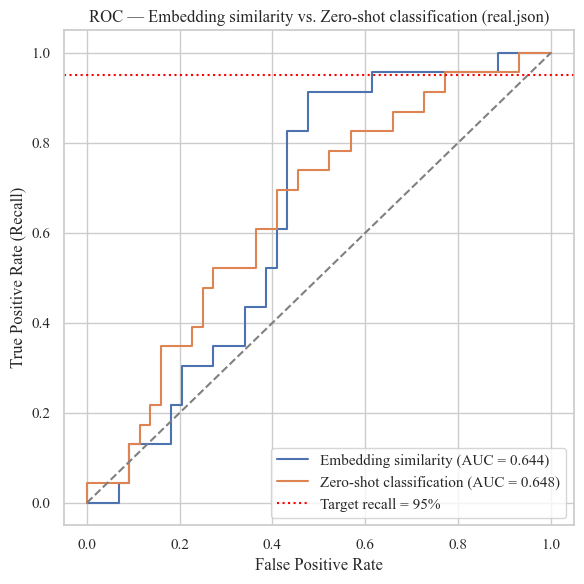

Embedding similarity on real.json -> flagged: 49 (73.13%)
Zero-shot classification on real.json -> flagged: 56 (83.58%)

union on real.json
  selected: 62/67
  recall: 1.000
  precision: 0.371
  specificity: 0.114
  f1: 0.541
  wss@95: 0.025
  confusion matrix:
[[ 5 39]
 [ 0 23]]

intersection on real.json
  selected: 43/67
  recall: 0.913
  precision: 0.488
  specificity: 0.500
  f1: 0.636
  wss@95: 0.308
  confusion matrix:
[[22 22]
 [ 2 21]]


In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
for score_col, name in [("embedding_score", "Embedding similarity"),
                         ("zeroshot_score", "Zero-shot classification")]:
    fpr, tpr, _ = roc_curve(df_real["label"], df_real[score_col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.axhline(CONFIG["TARGET_RECALL"], color="red", linestyle=":", label=f"Target recall = {CONFIG['TARGET_RECALL']:.0%}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC — Embedding similarity vs. Zero-shot classification (real.json)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Embedding similarity": embedding_stats,
    "Zero-shot classification": zeroshot_stats,
}).T
comparison

# Summary of the same decision counts on the labeled real.json set
for score_col, name in [("embedding_score", "Embedding similarity"), ("zeroshot_score", "Zero-shot classification")]:
    threshold = embedding_stats["threshold"] if score_col == "embedding_score" else zeroshot_stats["threshold"]
    preds = (df_real[score_col] >= threshold).astype(int)
    positives = int(preds.sum())
    pct = positives / len(df_real) * 100 if len(df_real) else 0.0
    print(f"{name} on real.json -> flagged: {positives} ({pct:.2f}%)")

# Extended metrics for the combined decision rules on the labeled real.json set
real_labels = df_real["label"].to_numpy()
real_embedding = (df_real["embedding_score"] >= embedding_stats["threshold"]).astype(int).to_numpy()
real_zeroshot = (df_real["zeroshot_score"] >= zeroshot_stats["threshold"]).astype(int).to_numpy()
real_union = (real_embedding | real_zeroshot).astype(int)
real_intersection = (real_embedding & real_zeroshot).astype(int)

for name, preds in [("union", real_union), ("intersection", real_intersection)]:
    tn, fp, fn, tp = _confusion_counts(real_labels, preds)
    n = len(real_labels)
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan
    wss = (tn + fn) / n - (1 - CONFIG["TARGET_RECALL"])

    print(f"\n{name} on real.json")
    print(f"  selected: {int(preds.sum())}/{n}")
    print(f"  recall: {recall:.3f}")
    print(f"  precision: {precision:.3f}")
    print(f"  specificity: {specificity:.3f}")
    print(f"  f1: {f1:.3f}")
    print(f"  wss@{int(CONFIG['TARGET_RECALL']*100)}: {wss:.3f}")
    print("  confusion matrix:")
    print(confusion_matrix(real_labels, preds))

## Step 2 — Apply the calibrated methods to the full corpus

Mesmo arquivo usado pelo notebook original (`MAIN_DATA_PATH`). Calculamos os dois
scores para cada registro, aplicamos os thresholds calibrados no passo anterior, e
guardamos as colunas de decisão de cada método além de uma versão "union" (positivo
em pelo menos um dos dois) — que prioriza recall na triagem, na mesma lógica adotada
para a query do Scopus. Ajuste esse critério na Step 3 se preferir "intersection"
(exige os dois métodos concordarem) ou apenas um dos métodos isoladamente.

In [13]:
with open(CONFIG["MAIN_DATA_PATH"], "r", encoding="utf8") as f:
    corpus_data = json.load(f)

df_corpus = pd.DataFrame(corpus_data)
df_corpus["text"] = df_corpus.apply(lambda r: get_text(r.to_dict()), axis=1)

missing = df_corpus["text"].isna().sum()
if missing:
    print(f"WARNING: {missing}/{len(df_corpus)} corpus records have no usable text field "
          f"— these will be scored as not-related by default.")

print(f"Loaded {len(df_corpus)} corpus records")
df_corpus.head(3)

Loaded 1445 corpus records


,title,authors,journal,doi,publication_date,document_type,prism:url,scopus_id,abstract,author_keywords,subject_areas,introduction,contribution,text
0,Intelligent assessment and diagnosis of street space quality using visual transformers,Xie J.,Discover Artificial Intelligence,10.1007/s44163-026-01409-7,2026,Article,https://api.elsevier.com/content/abstract/scopus_id/105045280156,105045280156,Addressing the demand for street-level spatial renewal in the context of high-quality urban deve...,"[Machine learning evaluation, Semantic segmentation, Street-level spatial quality, TrueSkill alg...","[Information Systems, Human-Computer Interaction, Computer Vision and Pattern Recognition, Artif...",Addressing the demand for street-level spatial renewal in the context of high-quality urban deve...,Addressing the demand for street-level spatial renewal in the context of high-quality urban deve...,Addressing the demand for street-level spatial renewal in the context of high-quality urban deve...
1,"More trees, more restorativeness? Exploring the influence of campus pedestrian space on stress r...",Mai S.,Computational Urban Science,10.1007/s43762-026-00286-1,2026,Article,https://api.elsevier.com/content/abstract/scopus_id/105046083709,105046083709,Campus pedestrian environments play a critical role in alleviating student stress through enviro...,"[Computer vision, Restoration, Street-view imagery, Stress recovery, Walkable campus environments]","[Environmental Science (miscellaneous), Urban Studies, Computer Science Applications, Artificial...",Campus pedestrian environments play a critical role in alleviating student stress through enviro...,"To address these gaps, we propose a scalable approach combining street-view imagery (SVI) and ma...","To address these gaps, we propose a scalable approach combining street-view imagery (SVI) and ma..."
2,Examining streetscape visuals and emotional responses through social media and street view image...,Yang X.,International Journal of Health Geographics,10.1186/s12942-025-00440-8,2026,Article,https://api.elsevier.com/content/abstract/scopus_id/105030690154,105030690154,"Background: Streets are important spaces for everyday activities, and the street environment can...","[Historic district, Semantic segmentation, Sina weibo microblog, Street view image (SVI), Visual...","[Computer Science (all), Business, Management and Accounting (all), Public Health, Environmental...","Background: Streets are important spaces for everyday activities, and the street environment can...",This study investigates the impact of streetscape visuals on public emotions in the Beishan Stre...,This study investigates the impact of streetscape visuals on public emotions in the Beishan Stre...


In [14]:
tqdm.pandas(desc="Embedding similarity (full corpus)")
df_corpus["embedding_score"] = df_corpus["text"].progress_apply(
    lambda t: embedding_score(t) if isinstance(t, str) and t.strip() else np.nan
)

tqdm.pandas(desc="Zero-shot classification (full corpus)")
df_corpus["zeroshot_score"] = df_corpus["text"].progress_apply(
    lambda t: zeroshot_score(t) if isinstance(t, str) and t.strip() else np.nan
)

df_corpus["is_walkability_embedding"] = df_corpus["embedding_score"] >= embedding_stats["threshold"]
df_corpus["is_walkability_zeroshot"] = df_corpus["zeroshot_score"] >= zeroshot_stats["threshold"]
df_corpus["is_walkability_either"] = df_corpus["is_walkability_embedding"] | df_corpus["is_walkability_zeroshot"]
df_corpus["is_walkability_both"] = df_corpus["is_walkability_embedding"] & df_corpus["is_walkability_zeroshot"]

print(f"Flagged by embedding only:  {df_corpus['is_walkability_embedding'].sum()} "
      f"({df_corpus['is_walkability_embedding'].mean()*100:.2f}%)")
print(f"Flagged by zero-shot only:  {df_corpus['is_walkability_zeroshot'].sum()} "
      f"({df_corpus['is_walkability_zeroshot'].mean()*100:.2f}%)")
print(f"Flagged by either (union):  {df_corpus['is_walkability_either'].sum()} "
      f"({df_corpus['is_walkability_either'].mean()*100:.2f}%)")
print(f"Flagged by both (intersect):{df_corpus['is_walkability_both'].sum()} "
      f"({df_corpus['is_walkability_both'].mean()*100:.2f}%)")

Embedding similarity (full corpus):   0%|          | 0/1445 [00:00<?, ?it/s]

Zero-shot classification (full corpus):   0%|          | 0/1445 [00:00<?, ?it/s]

Flagged by embedding only:  996 (68.93%)
Flagged by zero-shot only:  1152 (79.72%)
Flagged by either (union):  1305 (90.31%)
Flagged by both (intersect):843 (58.34%)


## Step 3 — Save results

Salva três artefatos em `OUTPUT_DIR`:

1. `05_full_corpus_with_embedding_zeroshot_scores.json` — corpus completo com os dois
   scores e as quatro colunas de decisão, para auditoria e reprodutibilidade.
2. `05_filtered_walkability_applications.json` — subconjunto filtrado (critério union,
   mesmo nome de arquivo do notebook original, para não quebrar o resto do pipeline).
3. `05_validation_metrics.json` — as métricas de validação no `real.json` (recall,
   precision, F1, WSS@95, thresholds), para documentar a decisão no protocolo PRISMA.

In [15]:
FILTER_COLUMN = "is_walkability_either"  # troque para is_walkability_both / _embedding / _zeroshot se preferir

output_full_path = os.path.join(CONFIG["OUTPUT_DIR"], "05_full_corpus_with_embedding_zeroshot_scores.json")
output_filtered_path = os.path.join(CONFIG["OUTPUT_DIR"], "05_filtered_walkability_applications.json")
output_metrics_path = os.path.join(CONFIG["OUTPUT_DIR"], "05_validation_metrics.json")

df_corpus.to_json(output_full_path, orient="records", indent=4)

filtered = df_corpus[df_corpus[FILTER_COLUMN] == True]
filtered.to_json(output_filtered_path, orient="records", indent=4)

metrics_report = {
    "target_recall": CONFIG["TARGET_RECALL"],
    "real_json_n": len(df_real),
    "real_json_n_positive": int(df_real["label"].sum()),
    "embedding": {**embedding_stats, "model": CONFIG["EMBEDDING_MODEL_NAME"],
                  "anchor": CONFIG["POSITIVE_ANCHOR"]},
    "zeroshot": {**zeroshot_stats, "model": CONFIG["ZEROSHOT_MODEL_NAME"],
                 "candidate_labels": CONFIG["ZEROSHOT_CANDIDATE_LABELS"],
                 "hypothesis_template": CONFIG["ZEROSHOT_HYPOTHESIS_TEMPLATE"]},
    "corpus_filter_column_used": FILTER_COLUMN,
    "corpus_n_total": len(df_corpus),
    "corpus_n_filtered": int(len(filtered)),
}
with open(output_metrics_path, "w", encoding="utf8") as f:
    json.dump(metrics_report, f, indent=2)

print(f"Total corpus records: {len(df_corpus)}")
print(f"Filtered records ({FILTER_COLUMN}): {len(filtered)}")
print(f"Saved:\n  {output_full_path}\n  {output_filtered_path}\n  {output_metrics_path}")

Total corpus records: 1445
Filtered records (is_walkability_either): 1305
Saved:
  ../data\05_full_corpus_with_embedding_zeroshot_scores.json
  ../data\05_filtered_walkability_applications.json
  ../data\05_validation_metrics.json


## Additional evaluation on test.json and val.json

Este bloco repete o mesmo fluxo do `real.json` para `test.json` e `val.json`, usando os mesmos thresholds calibrados no conjunto real para gerar métricas comparáveis de recall, precision, F1, WSS e matriz de confusão.

In [ ]:
def evaluate_dataset(df_eval, dataset_name):
    df_eval = df_eval.copy()
    df_eval["text"] = df_eval.apply(lambda r: get_text(r.to_dict()), axis=1)
    df_eval["label"] = df_eval.apply(lambda r: get_label(r.to_dict()), axis=1)
    df_eval = df_eval.dropna(subset=["text", "label"]).reset_index(drop=True)
    df_eval["label"] = df_eval["label"].astype(int)

    print(f"\n=== {dataset_name} ===")
    print(f"Loaded {len(df_eval)} records ({df_eval['label'].sum()} positive, {(df_eval['label']==0).sum()} negative)")

    tqdm.pandas(desc=f"Embedding similarity ({dataset_name})")
    df_eval["embedding_score"] = df_eval["text"].progress_apply(embedding_score)

    tqdm.pandas(desc=f"Zero-shot classification ({dataset_name})")
    df_eval["zeroshot_score"] = df_eval["text"].progress_apply(zeroshot_score)

    embedding_pred = (df_eval["embedding_score"] >= embedding_stats["threshold"]).astype(int)
    zeroshot_pred = (df_eval["zeroshot_score"] >= zeroshot_stats["threshold"]).astype(int)
    union_pred = (embedding_pred | zeroshot_pred).astype(int)
    intersection_pred = (embedding_pred & zeroshot_pred).astype(int)

    for name, preds in [("embedding", embedding_pred), ("zeroshot", zeroshot_pred), ("union", union_pred), ("intersection", intersection_pred)]:
        tn, fp, fn, tp = _confusion_counts(df_eval["label"].to_numpy(), preds.to_numpy())
        n = len(df_eval)
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        precision = tp / (tp + fp) if (tp + fp) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan
        wss = (tn + fn) / n - (1 - CONFIG["TARGET_RECALL"])

        print(f"\n{name} -> selected: {int(preds.sum())}/{n}")
        print(f"  recall: {recall:.3f}")
        print(f"  precision: {precision:.3f}")
        print(f"  specificity: {specificity:.3f}")
        print(f"  f1: {f1:.3f}")
        print(f"  wss@{int(CONFIG['TARGET_RECALL']*100)}: {wss:.3f}")
        print("  confusion matrix:")
        print(confusion_matrix(df_eval["label"].to_numpy(), preds.to_numpy()))


def load_dataset(path):
    with open(path, "r", encoding="utf8") as f:
        return pd.DataFrame(json.load(f))

for dataset_name, dataset_path in [("test", "../model/dataset/test.json"), ("val", "../model/dataset/val.json")]:
    df_eval = load_dataset(dataset_path)
    evaluate_dataset(df_eval, dataset_name)



=== test ===
Loaded 316 records (145 positive, 171 negative)


Embedding similarity (test):   0%|          | 0/316 [00:00<?, ?it/s]

Zero-shot classification (test):   0%|          | 0/316 [00:00<?, ?it/s]


embedding -> selected: 239/316
  recall: 0.876
  precision: 0.531
  specificity: 0.345
  f1: 0.661
  wss@95: 0.194
  confusion matrix:
[[ 59 112]
 [ 18 127]]

zeroshot -> selected: 228/316
  recall: 0.931
  precision: 0.592
  specificity: 0.456
  f1: 0.724
  wss@95: 0.228
  confusion matrix:
[[ 78  93]
 [ 10 135]]

union -> selected: 280/316
  recall: 0.986
  precision: 0.511
  specificity: 0.199
  f1: 0.673
  wss@95: 0.064
  confusion matrix:
[[ 34 137]
 [  2 143]]

intersection -> selected: 187/316
  recall: 0.821
  precision: 0.636
  specificity: 0.602
  f1: 0.717
  wss@95: 0.358
  confusion matrix:
[[103  68]
 [ 26 119]]


FileNotFoundError: [Errno 2] No such file or directory: '../model/dataset/val.json'

: 